In [1]:
import warnings
warnings.filterwarnings("ignore")
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()


Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

가중치와 바이어스를 계산할 데이터를 만든다.

In [3]:
xData = [2, 4, 6, 8] # 공부 시간
yData = [81, 93, 91, 97] # 공부 시간에 따른 시험 점수 => 실제값

공부 시간과 공부 시간에 따른 시험 점수 데이터를 판다스 데이터프레임으로 만든다.

In [4]:
df = pd.DataFrame(columns=['x', 'y'])
df.loc[0] = [2, 81]
df.loc[1] = [4, 93]
df.loc[2] = [6, 91]
df.loc[3] = [8, 97]
df

,x,y
0,2,81
1,4,93
2,6,91
3,8,97


공부 시간과 공부 시간에 따른 시험 점수 시각화

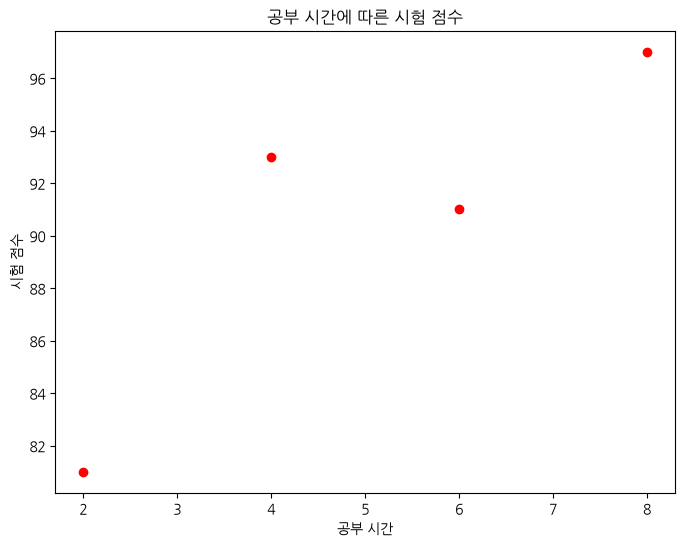

In [16]:
plt.figure(figsize=(8, 6))
plt.plot(df.x, df.y, 'or')
plt.title('공부 시간에 따른 시험 점수')
plt.xlabel('공부 시간')
plt.ylabel('시험 점수')
plt.show()

가중치 공식

$$\frac{\sum_{i=0}^{n-1}(x_i-\bar x)(y_i-\bar y)}{\sum_{i=0}^{n-1}(x_i-\bar x)^2}$$

In [6]:
# 공부 시간과 공부 시간에 따른 시험 점수의 평균을 계산한다.
x_mean = np.mean(df.x)
y_mean = np.mean(df.y)
print(f'공부 시간의 평균: {x_mean}, 공부 시간에 따른 시험 점수의 평균: {y_mean}')

공부 시간의 평균: 5.0, 공부 시간에 따른 시험 점수의 평균: 90.5


In [10]:
# 가중치 공식에서 분자를 계산하는 함수
def top(xData, x_mean, yData, y_mean):
    total = 0.0
    for i in range(len(xData)):
        total += (xData[i] - x_mean) * (yData[i] - y_mean)
    return total

numerator = top(xData, x_mean, yData, y_mean)
print(numerator)

46.0


In [11]:
# 가중치 공식에서 분모를 계산하는 함수
def bottom(xData, x_mean):
    total = 0.0
    for i in range(len(xData)):
        total += (xData[i] - x_mean) ** 2
    return total

denominator = bottom(xData, x_mean)
print(denominator)

20.0


In [14]:
print(f'가중치 공식의 분자: {numerator}, 가중치 공식의 분모: {denominator}')
a = numerator / denominator
print(f'가중치: {a}')

가중치 공식의 분자: 46.0, 가중치 공식의 분모: 20.0
가중치: 2.3


바이어스 공식

$$\bar y-a\bar x$$

In [15]:
b = y_mean - a * x_mean
print(f'바이어스: {b}')

바이어스: 79.0
